In [1]:
# Silence noisy logs BEFORE importing Curator / Ray / NeMo.
import contextlib
import logging
import os
import sys
import warnings
from collections.abc import Iterator

# Ensure the active venv's `ray` CLI is on PATH (needed for RayClient.start()).
_venv_bin = os.path.dirname(sys.executable)
if os.path.isdir(_venv_bin):
    os.environ["PATH"] = _venv_bin + os.pathsep + os.environ.get("PATH", "")

# Curator uses loguru; NeMo uses Python logging; Ray forwards worker stdout to the driver.
os.environ["LOGURU_LEVEL"] = "ERROR"
os.environ["NEMO_LOG_LEVEL"] = "ERROR"
os.environ.setdefault("RAY_BACKEND_LOG_LEVEL", "error")
os.environ.setdefault("RAY_DEDUP_LOGS", "1")

warnings.filterwarnings("ignore", message=r".*concurrency.*deprecated.*")
warnings.filterwarnings("ignore", message=r".*num_cpus and num_gpus.*experimental.*")


def _silence_third_party_loggers() -> None:
    logging.getLogger("nemo_logger").setLevel(logging.ERROR)
    for name in ("ray", "ray.data", "ray.worker", "ray.util", "urllib3", "matplotlib", "filelock"):
        logging.getLogger(name).setLevel(logging.ERROR)


def configure_loguru() -> None:
    from loguru import logger

    logger.remove()
    logger.add(sys.stderr, level="ERROR")


def configure_quiet_ray() -> None:
    """Disable Ray Data progress bars without pre-initing Ray on the driver.

    Do not call ray.init() here: a driver-side init (especially with
    log_to_driver=False) breaks cosmos_xenna GPU resource discovery even when
    the cluster exposes GPUs. XennaExecutor / RayDataExecutor connect themselves.
    """
    from ray.data import DataContext

    ctx = DataContext.get_current()
    ctx.enable_progress_bars = False
    ctx.enable_operator_progress_bars = False
    ctx.use_ray_tqdm = False

    _silence_third_party_loggers()


@contextlib.contextmanager
def quiet_pipeline_run() -> Iterator[None]:
    """Suppress Ray / NeMo / Xenna driver noise during pipeline.run()."""
    configure_loguru()
    _silence_third_party_loggers()
    with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
        yield



# Curating the FLEURS Dataset with NeMo Curator

This notebook walks through the FLEURS audio curation pipeline step by step:
1. Download a small FLEURS split
2. Run ASR inference
3. Compute WER and duration
4. Filter by WER threshold
5. Inspect and visualize results

**Requirements**: GPU recommended for ASR inference. Install with `uv sync --extra audio_cuda12`.

In [2]:
import json
import os
import shutil

from nemo_curator.backends.xenna import XennaExecutor
from nemo_curator.core.client import RayClient
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.audio.common import GetAudioDurationStage, PreserveByValueStage
from nemo_curator.stages.audio.datasets.fleurs.create_initial_manifest import CreateInitialManifestFleursStage
from nemo_curator.stages.audio.inference.asr.asr_nemo import InferenceAsrNemoStage
from nemo_curator.stages.audio.io.convert import AudioToDocumentStage
from nemo_curator.stages.audio.metrics.wer import GetPairwiseWerStage
from nemo_curator.stages.resources import Resources
from nemo_curator.stages.text.io.writer import JsonlWriter

configure_loguru()
_silence_third_party_loggers()

[NeMo W 2026-06-11 22:09:27 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.


2026-06-11 22:09:27,454 - WARNING - OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.


2026-06-11 22:09:27,476 - INFO - Final configuration contains 0 exporter(s)


2026-06-11 22:09:27,477 - WARNING - No exporters were provided. This means that no telemetry data will be collected.


## Configuration

Adjust these parameters for your setup:

In [3]:
RAW_DATA_DIR = os.path.abspath("./example_audio/fleurs")
LANG = "hy_am"
SPLIT = "dev"  # matches audio_fleurs_benchmark.py default (nightly CI uses train)
MODEL_NAME = "nvidia/stt_hy_fastconformer_hybrid_large_pc"
WER_THRESHOLD = 5.5
GPUS = 1.0

RESULT_DIR = os.path.join(RAW_DATA_DIR, "result", LANG)
if os.path.isdir(RESULT_DIR):
    shutil.rmtree(RESULT_DIR)

## Step 1: Build the pipeline

The pipeline has 7 stages: download → ASR → WER → duration → filter → convert → write.
We define a function so we can rebuild the pipeline for each backend run.

In [4]:
def build_pipeline(result_dir: str) -> Pipeline:
    """Create a fresh pipeline writing to *result_dir*."""
    if os.path.isdir(result_dir):
        shutil.rmtree(result_dir)
    p = Pipeline(name="fleurs_tutorial", description="Download FLEURS, run ASR, filter by WER")
    p.add_stage(
        CreateInitialManifestFleursStage(lang=LANG, split=SPLIT, raw_data_dir=RAW_DATA_DIR).with_(batch_size=4)
    )
    p.add_stage(InferenceAsrNemoStage(model_name=MODEL_NAME).with_(resources=Resources(gpus=GPUS)))
    p.add_stage(GetPairwiseWerStage(text_key="text", pred_text_key="pred_text", wer_key="wer_pct"))
    p.add_stage(GetAudioDurationStage(audio_filepath_key="audio_filepath", duration_key="duration"))
    p.add_stage(PreserveByValueStage(input_value_key="wer_pct", target_value=WER_THRESHOLD, operator="le"))
    p.add_stage(AudioToDocumentStage().with_(batch_size=1))
    p.add_stage(JsonlWriter(path=result_dir, write_kwargs={"force_ascii": False}))
    return p


print(build_pipeline(RESULT_DIR).describe())


Pipeline: fleurs_tutorial
Description: Download FLEURS, run ASR, filter by WER
Stages: 7

Stage 1: CreateInitialManifestFleurs
  Resources: 1.0 CPUs
  Batch size: 4
  Outputs:
    Output columns: audio_filepath, text
Stage 2: ASR_inference
  Resources: 1.0 CPUs
    GPU Memory: 0.0 GB (1.0 GPUs)
  Batch size: 16
  Inputs:
    Required columns: audio_filepath
  Outputs:
    Output columns: audio_filepath, pred_text
Stage 3: GetPairwiseWerStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: text, pred_text
  Outputs:
    Output columns: text, pred_text, wer_pct
Stage 4: GetAudioDurationStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: audio_filepath
  Outputs:
    Output columns: duration
Stage 5: PreserveByValueStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: wer_pct
  Outputs:
    Output columns: wer_pct
Stage 6: AudioToDocumentStage
  Resources: 1.0 CPUs
  Batch size: 1
Stage 7: jsonl_writer
  Resources: 1.0 CP

## Step 2: Execute the pipeline with both backends

`RayClient` manages the Ray cluster lifecycle (start/stop, port allocation, dashboard).
We run the pipeline with **both** backends and compare results and timing.

In [5]:
import time

from nemo_curator.backends.ray_data import RayDataExecutor

# Avoid attaching to a stale Ray cluster left over from a prior notebook run.
os.environ.pop("RAY_ADDRESS", None)

ray_client = RayClient(num_gpus=int(GPUS))
ray_client.start()
configure_quiet_ray()


def load_results(result_dir: str) -> list[dict]:
    """Read all JSONL files from a result directory."""
    data = []
    for fname in os.listdir(result_dir):
        if fname.endswith(".jsonl"):
            with open(os.path.join(result_dir, fname)) as f:
                data.extend(json.loads(line) for line in f if line.strip())
    return data


backends = {
    "xenna": XennaExecutor,
    "ray_data": RayDataExecutor,
}

run_results = {}

for name, executor_cls in backends.items():
    result_dir = os.path.join(RAW_DATA_DIR, f"result_{name}")
    pipeline = build_pipeline(result_dir)
    executor = executor_cls()

    t0 = time.time()
    with quiet_pipeline_run():
        pipeline.run(executor)
    elapsed = time.time() - t0

    data = load_results(result_dir)
    wers = [r.get("wer_pct", 0) for r in data]

    run_results[name] = {
        "time": elapsed,
        "samples": len(data),
        "mean_wer": sum(wers) / len(wers) if wers else 0,
        "total_dur": sum(r.get("duration", 0) for r in data),
        "data": data,
    }
    print(f"[{name}] {elapsed:.2f}s — {len(data)} samples, mean WER {run_results[name]['mean_wer']:.1f}%")

2026-06-11 22:09:30,410	INFO usage_lib.py:448 -- Usage stats collection is disabled.
2026-06-11 22:09:30,410	INFO scripts.py:940 -- Local node IP: 127.0.1.1
2026-06-11 22:09:37,249	SUCC scripts.py:979 -- --------------------
2026-06-11 22:09:37,249	SUCC scripts.py:980 -- Ray runtime started.
2026-06-11 22:09:37,249	SUCC scripts.py:981 -- --------------------
2026-06-11 22:09:37,249	INFO scripts.py:983 -- Next steps
2026-06-11 22:09:37,250	INFO scripts.py:986 -- To add another node to this Ray cluster, run
2026-06-11 22:09:37,250	INFO scripts.py:989 --   ray start --address='127.0.1.1:6379'
2026-06-11 22:09:37,250	INFO scripts.py:1000 -- To connect to this Ray cluster:
2026-06-11 22:09:37,250	INFO scripts.py:1002 -- import ray
2026-06-11 22:09:37,250	INFO scripts.py:1003 -- ray.init(_node_ip_address='127.0.1.1')
2026-06-11 22:09:37,250	INFO scripts.py:1017 -- To submit a Ray job using the Ray Jobs CLI:
2026-06-11 22:09:37,250	INFO scripts.py:1018 --   RAY_API_SERVER_ADDRESS='http://127.

2026-06-11 22:09:38,676	INFO worker.py:1672 -- Using address 127.0.1.1:6379 set in the environment variable RAY_ADDRESS


2026-06-11 22:09:38,681	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 127.0.1.1:6379...


2026-06-11 22:09:38,710	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 


[2026-06-11 22:09:38,712 I 723237 723237] logging.cc:303: Set ray log level from environment variable RAY_BACKEND_LOG_LEVEL to 2


...

2026-06-11 22:10:27,806	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 127.0.1.1:6379...


2026-06-11 22:10:27,827	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 


[xenna] 49.13s — 50 samples, mean WER 2.6%


[2026-06-11 22:10:39,317 E 723237 723237] core_worker.cc:2194: Actor with class name: 'MapWorker(MapBatches(FleursAsrStageActor))' and ID: '137913df0e59ce3cb8cf2e5c02000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.


[ray_data] 39.26s — 50 samples, mean WER 2.6%


In [6]:
MATCH_TOL = 0.1

print("\n" + "=" * 60)
print("Backend Comparison")
print("=" * 60)
print(f"{'':>12s}  {'Xenna':>10s}  {'Ray Data':>10s}  {'Match':>6s}")
print(f"{'Time (s)':>12s}  {run_results['xenna']['time']:10.2f}  {run_results['ray_data']['time']:10.2f}  {'':>6s}")
print(
    f"{'Samples':>12s}  {run_results['xenna']['samples']:10d}  {run_results['ray_data']['samples']:10d}"
    f"  {'✓' if run_results['xenna']['samples'] == run_results['ray_data']['samples'] else '✗':>6s}"
)
print(
    f"{'Mean WER':>12s}  {run_results['xenna']['mean_wer']:10.1f}  {run_results['ray_data']['mean_wer']:10.1f}"
    f"  {'✓' if abs(run_results['xenna']['mean_wer'] - run_results['ray_data']['mean_wer']) < MATCH_TOL else '✗':>6s}"
)
print(
    f"{'Audio (s)':>12s}  {run_results['xenna']['total_dur']:10.1f}  {run_results['ray_data']['total_dur']:10.1f}"
    f"  {'✓' if abs(run_results['xenna']['total_dur'] - run_results['ray_data']['total_dur']) < MATCH_TOL else '✗':>6s}"
)
speedup = run_results["ray_data"]["time"] / run_results["xenna"]["time"]
faster = "xenna" if speedup > 1 else "ray_data"
print(f"\n→ {faster} was {max(speedup, 1 / speedup):.1f}x faster on this dataset")

results = run_results["xenna"]["data"]


Backend Comparison
                   Xenna    Ray Data   Match
    Time (s)       49.13       39.26        
     Samples          50          50       ✓
    Mean WER         2.6         2.6       ✓
   Audio (s)       554.0       554.0       ✓

→ ray_data was 1.3x faster on this dataset


## Step 3: Load and inspect results

In [7]:
print(f"Total samples after filtering: {len(results)}")
print("\nSample entry:")
print(json.dumps(results[0], indent=2, ensure_ascii=False) if results else "No results")

Total samples after filtering: 50

Sample entry:
{
  "audio_filepath": "/home/aaftabv/grananary-v2/references/CuratorPRReviews/tutorials/audio/fleurs/example_audio/fleurs/hy_am/dev/12606436530546538989.wav",
  "text": "Շատ դեպքերում, արտասահմանում մասնակցելով տարկետման դասընթացի, կարող եք իրականում բարելավել հայրենիքում բարձրագույն կրթական հաստատություն տեղափոխվելու ձեր հնարավորությունները։",
  "pred_text": "Շատ դեպքերում, արտասահմանում մասնակցելով տարկետման դասընթացի, կարող եք իրականում բարելավել հայրենիքում բարձրագույն կրթական հաստատություն տեղափոխվելու ձեր հնարավորությունները։",
  "wer_pct": 0.0,
  "duration": 12.3
}


## Step 4: Visualize results

### WER distribution

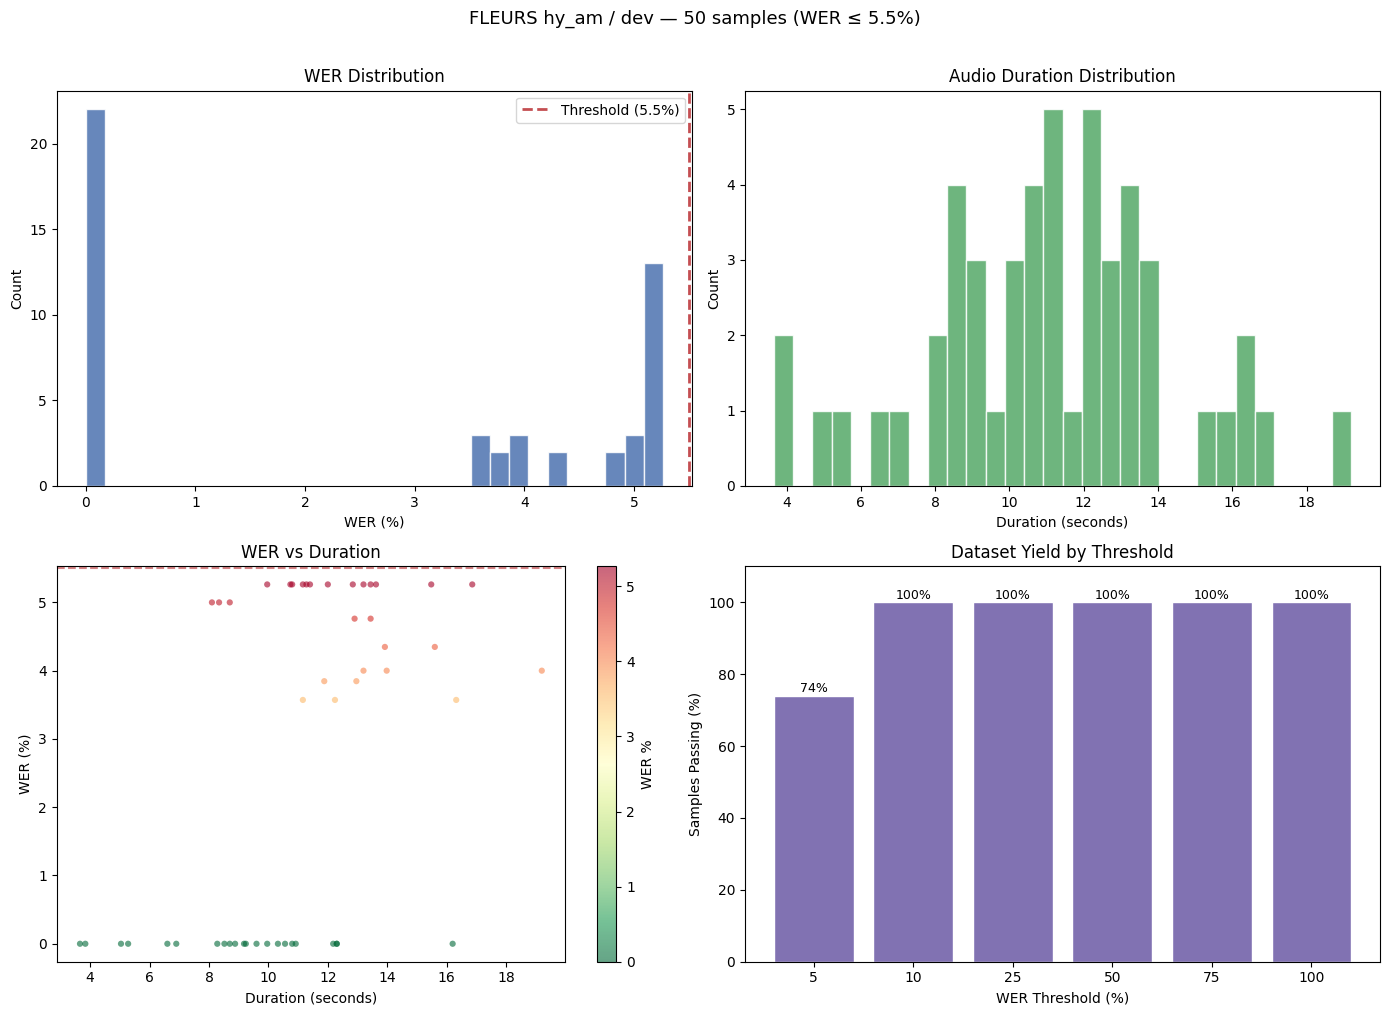


WER — min: 0.0%, max: 5.3%, mean: 2.6%, median: 3.7%
Duration — min: 3.66s, max: 19.20s, total: 554.0s


In [8]:
import matplotlib.pyplot as plt
import numpy as np

wers = [r.get("wer_pct", 0) for r in results]
durations = [r.get("duration", 0) for r in results]

if not wers:
    print("No results to visualize. Try relaxing WER_THRESHOLD or re-running the pipeline.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. WER histogram with threshold line
    ax = axes[0, 0]
    ax.hist(wers, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(WER_THRESHOLD, color="#C44E52", linestyle="--", linewidth=2, label=f"Threshold ({WER_THRESHOLD}%)")
    ax.set_xlabel("WER (%)")
    ax.set_ylabel("Count")
    ax.set_title("WER Distribution")
    ax.legend()

    # 2. Duration distribution
    ax = axes[0, 1]
    ax.hist(durations, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Audio Duration Distribution")

    # 3. WER vs Duration scatter
    ax = axes[1, 0]
    scatter = ax.scatter(durations, wers, c=wers, cmap="RdYlGn_r", alpha=0.6, s=20, edgecolors="none")
    ax.axhline(WER_THRESHOLD, color="#C44E52", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("WER (%)")
    ax.set_title("WER vs Duration")
    plt.colorbar(scatter, ax=ax, label="WER %")

    # 4. Pass rate at multiple thresholds
    ax = axes[1, 1]
    thresholds = [5, 10, 25, 50, 75, 100]
    pass_rates = [sum(1 for w in wers if w <= t) / len(wers) * 100 for t in thresholds]
    bars = ax.bar([str(t) for t in thresholds], pass_rates, color="#8172B2", edgecolor="white")
    ax.set_xlabel("WER Threshold (%)")
    ax.set_ylabel("Samples Passing (%)")
    ax.set_title("Dataset Yield by Threshold")
    for bar, rate in zip(bars, pass_rates, strict=True):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{rate:.0f}%", ha="center", fontsize=9)
    ax.set_ylim(0, 110)

    fig.suptitle(f"FLEURS {LANG} / {SPLIT} — {len(results)} samples (WER ≤ {WER_THRESHOLD}%)", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

    print(
        f"\nWER — min: {min(wers):.1f}%, max: {max(wers):.1f}%, mean: {np.mean(wers):.1f}%, median: {np.median(wers):.1f}%"
    )
    print(f"Duration — min: {min(durations):.2f}s, max: {max(durations):.2f}s, total: {sum(durations):.1f}s")

## Step 5: Experiment with different thresholds

Try changing the WER threshold to see how it affects the dataset size:

In [9]:
thresholds = [5, 5.5, 10, 25, 50, 75]
for t in thresholds:
    passing = [r for r in results if r.get("wer_pct", 100) <= t]
    pct = len(passing) / len(results) * 100 if results else 0
    print(f"  WER ≤ {t:4.1f}%: {len(passing):4d} samples ({pct:.0f}%)")

  WER ≤  5.0%:   37 samples (74%)
  WER ≤  5.5%:   50 samples (100%)
  WER ≤ 10.0%:   50 samples (100%)
  WER ≤ 25.0%:   50 samples (100%)
  WER ≤ 50.0%:   50 samples (100%)
  WER ≤ 75.0%:   50 samples (100%)


## Cleanup

Shut down the Ray cluster started by `RayClient`.

In [10]:
configure_loguru()
ray_client.stop()